In [27]:
import pandas as pd   # Untuk membuat dan mengolah DataFrame
import numpy as np    # Untuk operasi matematika (sqrt, array, dll)
import matplotlib.pyplot as plt   # Untuk membuat grafik/visualisasi
from sklearn.model_selection import train_test_split  # Membagi data train & test
from sklearn.linear_model import LogisticRegression   # Model regresi linear
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay # Mengukur akurasi model, tabel hasil prediksi vs aktual, laporan precision, recall, f1, dan  visualisasi confusion matrix

In [28]:
# Dataset
data = {
    'biaya_iklan': [1,2,3,4,5,6,7,8,9,10,11,12,13,14],           # Juta rupiah
    'jangkauan':   [30,44,53,57,65,68,74,79,83,87,90,93,95,99],  # % audiens
    'kreativitas': [5,5,6,6,7,7,7,8,8,8,9,9,9,9],                # Skor 1-10
    'durasi_iklan':[6,6,7,7,7,8,8,8,7,7,7,7,8,8],                # Jam tayang/hari
    'diskon':      [10,17,20,28,30,36,25,31,10,30,40,20,15,40],  # % diskon
    'berhasil':    [0,0,0,0,0,1,1,1,1,1,1,1,1,1]                 # 0=gagal, 1=berhasil
}

# Mengubah dictionary menjadi DataFrame agar mudah diolah
df = pd.DataFrame(data)
print(df)   # Menampilkan seluruh data dalam bentuk tabel

    biaya_iklan  jangkauan  kreativitas  durasi_iklan  diskon  berhasil
0             1         30            5             6      10         0
1             2         44            5             6      17         0
2             3         53            6             7      20         0
3             4         57            6             7      28         0
4             5         65            7             7      30         0
5             6         68            7             8      36         1
6             7         74            7             8      25         1
7             8         79            8             8      31         1
8             9         83            8             7      10         1
9            10         87            8             7      30         1
10           11         90            9             7      40         1
11           12         93            9             7      20         1
12           13         95            9             8      15   

In [29]:
# Menentukan Variabel
x = df[['biaya_iklan', 'jangkauan', 'kreativitas', 'durasi_iklan', 'diskon']]
y = df['berhasil']

In [30]:
# Split data train dan test
# Test_size=0.2 : 20% data untuk testing, 80% untuk training
# Random_state=42 : agar hasil pembagian selalu sama setiap dijalankan
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [31]:
# Membuat model regresi
# Max_iter=1000 → jumlah iterasi diperbesar agar model konvergen (tidak error
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
# Melihat atau menghitung koefisien
# Rumus: log(p/1-p) = a + b1*biaya_iklan + b2*jangkauan + b3*kreativitas + b4*durasi_iklan + b5*diskon
print("Intercept (a) :", model.intercept_[0])
print("Koefisien (b) :", model.coef_[0])

Intercept (a) : -57.1501730984277
Koefisien (b) : [0.18350967 0.68596802 0.00529471 0.1288533  0.29447855]


In [33]:
# Prediksi data testing
y_pred = model.predict(x_test)

print("Prediksi:", y_pred)
print("Aktual:", y_test.values)

Prediksi: [1 1 0]
Aktual: [1 1 0]


In [35]:
# Evaluasi
# Accuracy : persentase prediksi yang benar dari keseluruhan data testing
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy : 1.0
Confusion Matrix:
 [[1 0]
 [0 2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [37]:
# Prediksi
data_baru = np.array([[14, 90, 8, 7, 25]])

prediksi       = model.predict(data_baru)        # Prediksi kelas (0 atau 1)
prediksi_proba = model.predict_proba(data_baru)  # Prediksi probabilitas

print("Hasil  :", "Berhasil" if prediksi[0] == 1 else "Tidak Berhasil")
print("Probabilitas → Tidak Berhasil: {:.2f}%, Berhasil: {:.2f}%".format(
    prediksi_proba[0][0]*100,  # Probabilitas kelas 0 (tidak berhasil)
    prediksi_proba[0][1]*100   # Probabilitas kelas 1 (berhasil)
))

Hasil  : Berhasil
Probabilitas → Tidak Berhasil: 0.00%, Berhasil: 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


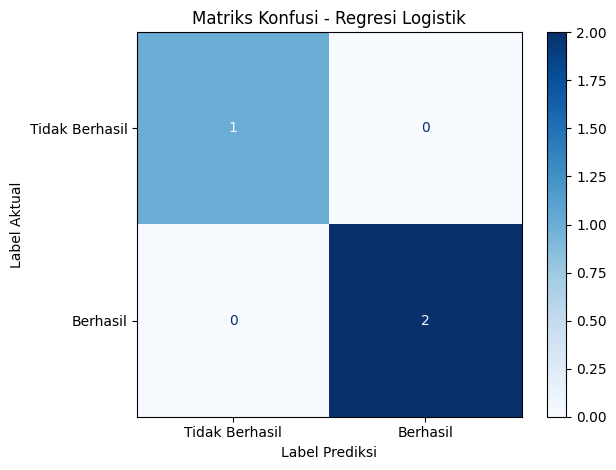

In [47]:
cm = confusion_matrix(y_test, y_pred)  # Hitung confusion matrix

# Membuat tampilan confusion matrix dengan label yang mudah dibaca
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Berhasil", "Berhasil"]  # Label kelas 0 dan 1
)

disp.plot(cmap='Blues')
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.title("Matriks Konfusi - Regresi Logistik")
plt.tight_layout()  # Agar layout tidak terpotong
plt.show()          # Menampilkan grafik